# Cricket Match Outcome Prediction
## ECE 2372 — Pattern Recognition | Anand Rai & Abdullah Mahmood
---
### Notebook Structure
- **Section 1:** Logistic Regression — all 6 feature packs
- **Section 2:** LDA — all 6 feature packs
- **Section 3:** SVM Linear — all 6 feature packs
- **Section 4:** Final Comparison — LogReg vs LDA vs SVM Linear
- **Section 5:** SVM Non-Linear (RBF) — all 6 feature packs

In [31]:
import sys
import os
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from models.logistic_regression import LogisticRegressionModel
from models.lda                 import LDAModel
from models.svm_model           import SVMModel
from models.svm_linear import SVMLinearModel

print('All imports OK.')

All imports OK.


In [3]:
df = pd.read_csv('data/training_table_v2.csv')
print(f'Data loaded. {len(df)} matches.')
print(f'Win rate (team1): {df["label_team1_win"].mean():.2%}')
print(f'Date range: {df["date_start"].min()} to {df["date_start"].max()}')
df.head()

Data loaded. 9691 matches.
Win rate (team1): 48.44%
Date range: 2005-02-17 to 2026-04-02


,match_id,date_start,source_bucket,official_status,competition_folder,event_name,match_type,gender,team1,team2,...,diff_prior_win_pct_at_venue,diff_prior_avg_runs_scored_at_venue,diff_prior_avg_runs_conceded_at_venue,diff_xi_players_with_venue_history,diff_xi_avg_venue_experience,diff_xi_avg_venue_batting_avg,diff_xi_avg_venue_strike_rate,diff_xi_avg_venue_bowling_avg,diff_xi_avg_venue_bowling_economy,diff_xi_avg_venue_wickets_per_match
0,211048,2005-02-17,international,official,t20Internationals_official,NaN,T20,male,New Zealand,Australia,...,0.0,0.0,0.0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
1,211028,2005-06-13,international,official,t20Internationals_official,NaN,T20,male,England,Australia,...,0.0,0.0,0.0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
2,222678,2005-10-21,international,official,t20Internationals_official,NaN,T20,male,South Africa,New Zealand,...,0.0,0.0,0.0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
3,226374,2006-01-09,international,official,t20Internationals_official,NaN,T20,male,Australia,South Africa,...,0.0,0.0,0.0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
4,238195,2006-02-24,international,official,t20Internationals_official,NaN,T20,male,South Africa,Australia,...,0.0,133.0,134.0,4,0.363636,6.818182,31.867375,5.272727,2.845694,0.0


In [4]:
PACK_A = [
    'diff_prior_matches', 'diff_prior_win_pct', 'diff_prior_avg_runs_scored',
    'diff_prior_avg_runs_conceded', 'diff_prior_run_rate', 'diff_prior_conceded_run_rate',
    'diff_last5_win_pct', 'diff_last5_avg_runs_scored', 'diff_last5_avg_runs_conceded',
    'toss_winner_is_team1', 'toss_winner_is_team2', 'team1_won_toss_and_batted',
    'team1_won_toss_and_fielded', 'team2_won_toss_and_batted', 'team2_won_toss_and_fielded',
]

PACK_B = PACK_A + [
    'diff_xi_players_with_history', 'diff_allrounder_count', 'diff_keeper_count',
    'diff_top_order_avg_batting_avg', 'diff_top_order_avg_strike_rate',
    'diff_middle_order_avg_batting_avg', 'diff_middle_order_avg_strike_rate',
    'diff_lower_order_avg_batting_avg', 'diff_lower_order_avg_strike_rate',
    'diff_top_order_pp_batting_avg', 'diff_top_order_pp_batting_strike_rate',
    'diff_middle_order_mid_batting_avg', 'diff_middle_order_mid_batting_strike_rate',
    'diff_lower_order_death_batting_avg', 'diff_lower_order_death_batting_strike_rate',
    'diff_bowlers_pp_bowling_avg', 'diff_bowlers_pp_bowling_strike_rate',
    'diff_bowlers_pp_bowling_economy', 'diff_bowlers_mid_bowling_avg',
    'diff_bowlers_mid_bowling_strike_rate', 'diff_bowlers_mid_bowling_economy',
    'diff_bowlers_death_bowling_avg', 'diff_bowlers_death_bowling_strike_rate',
    'diff_bowlers_death_bowling_economy',
]

PACK_C = PACK_A + [
    'venue_prior_matches', 'venue_prior_avg_first_innings_runs',
    'venue_prior_avg_second_innings_runs', 'venue_prior_chasing_win_pct',
    'venue_prior_defending_win_pct', 'diff_prior_matches_at_venue',
    'diff_prior_win_pct_at_venue', 'diff_prior_avg_runs_scored_at_venue',
    'diff_prior_avg_runs_conceded_at_venue', 'diff_xi_players_with_venue_history',
    'diff_xi_avg_venue_experience', 'diff_xi_avg_venue_batting_avg',
    'diff_xi_avg_venue_strike_rate', 'diff_xi_avg_venue_bowling_avg',
    'diff_xi_avg_venue_bowling_economy', 'diff_xi_avg_venue_wickets_per_match',
]

PACK_D = [
    'diff_prior_win_pct', 'diff_prior_avg_runs_scored', 'diff_prior_avg_runs_conceded',
    'diff_prior_run_rate', 'diff_last5_win_pct', 'diff_last5_avg_runs_scored',
    'diff_last5_avg_runs_conceded', 'toss_winner_is_team1', 'team1_won_toss_and_batted',
    'team1_won_toss_and_fielded', 'team2_won_toss_and_batted', 'team2_won_toss_and_fielded',
    'diff_xi_players_with_history', 'diff_allrounder_count',
    'diff_top_order_avg_batting_avg', 'diff_top_order_avg_strike_rate',
    'diff_middle_order_avg_batting_avg', 'diff_middle_order_avg_strike_rate',
    'diff_lower_order_death_batting_avg', 'diff_lower_order_death_batting_strike_rate',
    'diff_bowlers_pp_bowling_economy', 'diff_bowlers_mid_bowling_economy',
    'diff_bowlers_death_bowling_economy', 'venue_prior_avg_first_innings_runs',
    'venue_prior_avg_second_innings_runs', 'venue_prior_chasing_win_pct',
    'diff_prior_win_pct_at_venue', 'diff_xi_avg_venue_experience',
]

PACK_F = [
    'diff_prior_win_pct', 'diff_prior_avg_runs_scored', 'diff_prior_avg_runs_conceded',
    'diff_prior_run_rate', 'diff_last5_win_pct', 'toss_winner_is_team1',
    'team1_won_toss_and_batted', 'team1_won_toss_and_fielded',
    'diff_allrounder_count', 'diff_top_order_avg_batting_avg',
    'diff_middle_order_avg_strike_rate', 'diff_lower_order_death_batting_strike_rate',
    'diff_bowlers_death_bowling_economy', 'venue_prior_chasing_win_pct',
    'diff_prior_win_pct_at_venue',
]

EXCLUDE_COLS = [
    'match_id', 'date_start', 'source_bucket', 'official_status',
    'competition_folder', 'event_name', 'match_type', 'gender',
    'team1', 'team2', 'venue', 'city', 'toss_winner', 'toss_decision',
    'winner', 'label_team1_win', 'has_winner', 'is_binary_outcome',
]

PACK_E = [c for c in df.columns if c not in EXCLUDE_COLS]

PACKS = {
    'Pack A — Team only':        PACK_A,
    'Pack B — Team + Player':    PACK_B,
    'Pack C — Team + Venue':     PACK_C,
    'Pack D — Compact Combined': PACK_D,
    'Pack F — Minimalist':       PACK_F,
    'Pack E — Full V2':          PACK_E,
}

print('Feature packs defined:')
for name, pack in PACKS.items():
    print(f'  {name}: {len(pack)} features')

Feature packs defined:
  Pack A — Team only: 15 features
  Pack B — Team + Player: 39 features
  Pack C — Team + Venue: 31 features
  Pack D — Compact Combined: 28 features
  Pack F — Minimalist: 15 features
  Pack E — Full V2: 265 features


In [5]:
LABEL_COL = 'label_team1_win'
DATE_COL  = 'date_start'

def time_based_split(df, feature_cols, test_fraction=0.2):
    df_sorted = df.sort_values(DATE_COL).reset_index(drop=True)
    split_idx = int(len(df_sorted) * (1 - test_fraction))
    train_df  = df_sorted.iloc[:split_idx]
    test_df   = df_sorted.iloc[split_idx:]
    X_train = train_df[feature_cols].values
    X_test  = test_df[feature_cols].values
    y_train = train_df[LABEL_COL].values
    y_test  = test_df[LABEL_COL].values
    return X_train, X_test, y_train, y_test

def get_metrics(y_true, y_pred):
    return {
        'accuracy':  accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall':    recall_score(y_true, y_pred, zero_division=0),
        'f1':        f1_score(y_true, y_pred, zero_division=0),
        'cm':        confusion_matrix(y_true, y_pred),
    }

def plot_pack_results(results_dict, model_name):
    pack_names = list(results_dict.keys())
    accuracies  = [results_dict[p]['accuracy']  for p in pack_names]
    precisions  = [results_dict[p]['precision'] for p in pack_names]
    recalls     = [results_dict[p]['recall']    for p in pack_names]
    f1s         = [results_dict[p]['f1']        for p in pack_names]

    x     = np.arange(len(pack_names))
    width = 0.2

    fig, ax = plt.subplots(figsize=(13, 5))
    bars1 = ax.bar(x - 1.5*width, accuracies, width, label='Accuracy',  color='#4e79a7')
    bars2 = ax.bar(x - 0.5*width, precisions, width, label='Precision', color='#f28e2b')
    bars3 = ax.bar(x + 0.5*width, recalls,    width, label='Recall',    color='#e15759')
    bars4 = ax.bar(x + 1.5*width, f1s,        width, label='F1',        color='#76b7b2')

    for bars in [bars1, bars2, bars3, bars4]:
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.003,
                    f'{bar.get_height():.3f}',
                    ha='center', va='bottom', fontsize=7, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(pack_names, fontsize=9, rotation=15, ha='right')
    ax.set_ylim(0.5, 0.80)
    ax.set_ylabel('Score')
    ax.set_title(f'{model_name} — Performance Across All Feature Packs')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_confusion_matrices(results_dict, model_name):
    pack_names = list(results_dict.keys())
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()

    for ax, pack_name in zip(axes, pack_names):
        cm = results_dict[pack_name]['cm']
        ax.imshow(cm, interpolation='nearest', cmap='Blues')
        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_xticklabels(['Pred Loss', 'Pred Win'], fontsize=8)
        ax.set_yticklabels(['Act Loss', 'Act Win'], fontsize=8)
        for i in range(2):
            for j in range(2):
                ax.text(j, i, str(cm[i, j]),
                        ha='center', va='center',
                        fontsize=14, fontweight='bold',
                        color='white',
                        bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.4))
        acc = results_dict[pack_name]['accuracy']
        ax.set_title(f'{pack_name}\nAcc: {acc:.2%}', fontsize=9)

    plt.suptitle(f'{model_name} — Confusion Matrices', fontsize=13)
    plt.tight_layout()
    plt.show()

print('Helper functions defined.')

Helper functions defined.


---
## Section 1 — Logistic Regression

In [6]:
print('Training Logistic Regression on all packs...')
logreg_results = {}

for pack_name, feature_cols in PACKS.items():
    X_train, X_test, y_train, y_test = time_based_split(df, feature_cols)
    model = LogisticRegressionModel()
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    logreg_results[pack_name] = get_metrics(y_test, preds)
    print(f'  {pack_name}: Accuracy = {logreg_results[pack_name]["accuracy"]:.4f}')

print('\nDone.')

Training Logistic Regression on all packs...
[LogReg] Training done.
  Pack A — Team only: Accuracy = 0.6534
[LogReg] Training done.
  Pack B — Team + Player: Accuracy = 0.6447
[LogReg] Training done.
  Pack C — Team + Venue: Accuracy = 0.6380
[LogReg] Training done.
  Pack D — Compact Combined: Accuracy = 0.6421
[LogReg] Training done.
  Pack F — Minimalist: Accuracy = 0.6369
[LogReg] Training done.
  Pack E — Full V2: Accuracy = 0.6354

Done.


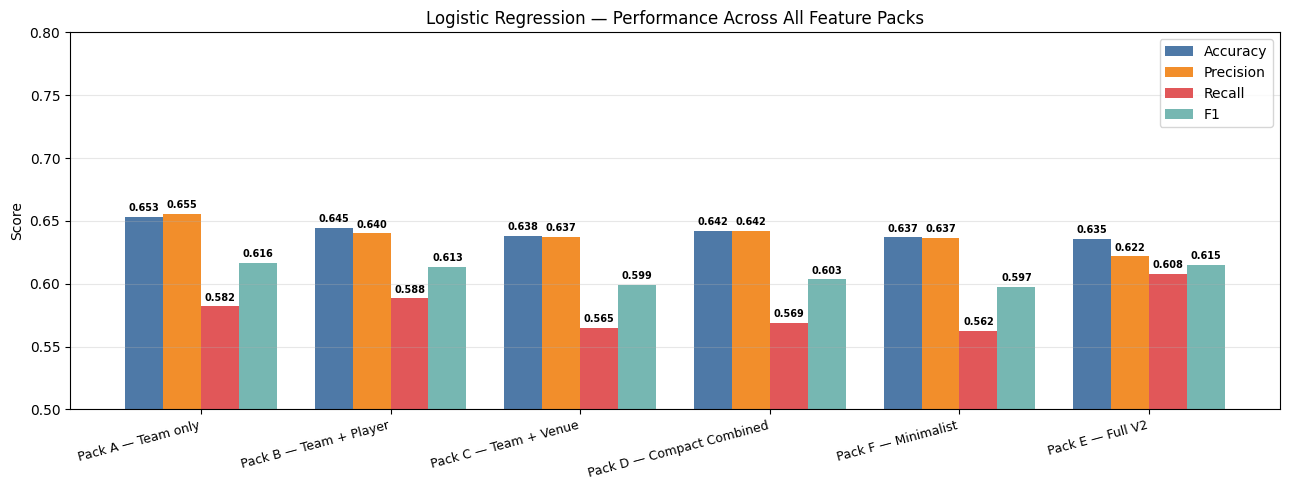

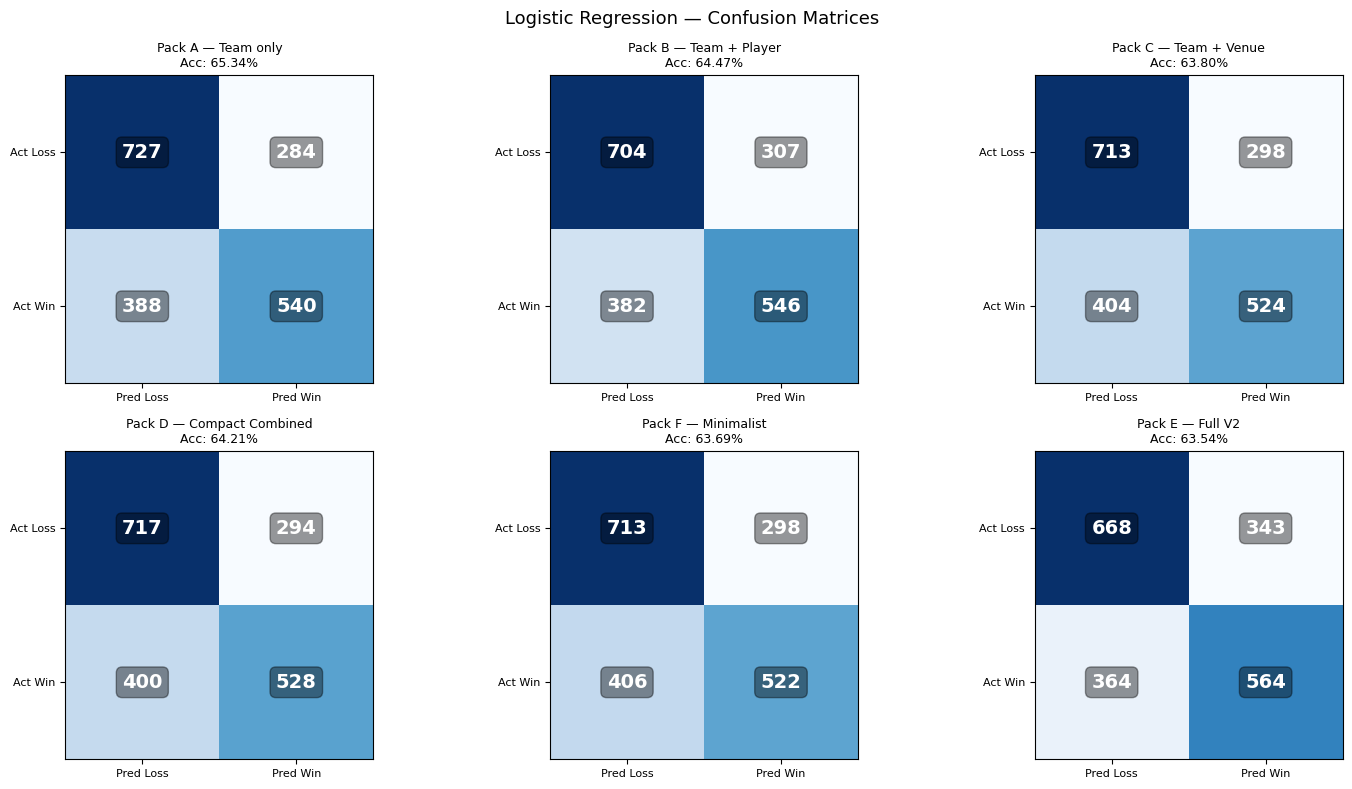

In [7]:
plot_pack_results(logreg_results, 'Logistic Regression')
plot_confusion_matrices(logreg_results, 'Logistic Regression')

---
## Section 2 — Linear Discriminant Analysis (LDA)

In [8]:
print('Training LDA on all packs...')
lda_results = {}

for pack_name, feature_cols in PACKS.items():
    X_train, X_test, y_train, y_test = time_based_split(df, feature_cols)
    model = LDAModel()
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    lda_results[pack_name] = get_metrics(y_test, preds)
    print(f'  {pack_name}: Accuracy = {lda_results[pack_name]["accuracy"]:.4f}')

print('\nDone.')

Training LDA on all packs...
[LDA] Training done.
  Pack A — Team only: Accuracy = 0.6524
[LDA] Training done.
  Pack B — Team + Player: Accuracy = 0.6503
[LDA] Training done.
  Pack C — Team + Venue: Accuracy = 0.6509
[LDA] Training done.
  Pack D — Compact Combined: Accuracy = 0.6411
[LDA] Training done.
  Pack F — Minimalist: Accuracy = 0.6374
[LDA] Training done.
  Pack E — Full V2: Accuracy = 0.6349

Done.


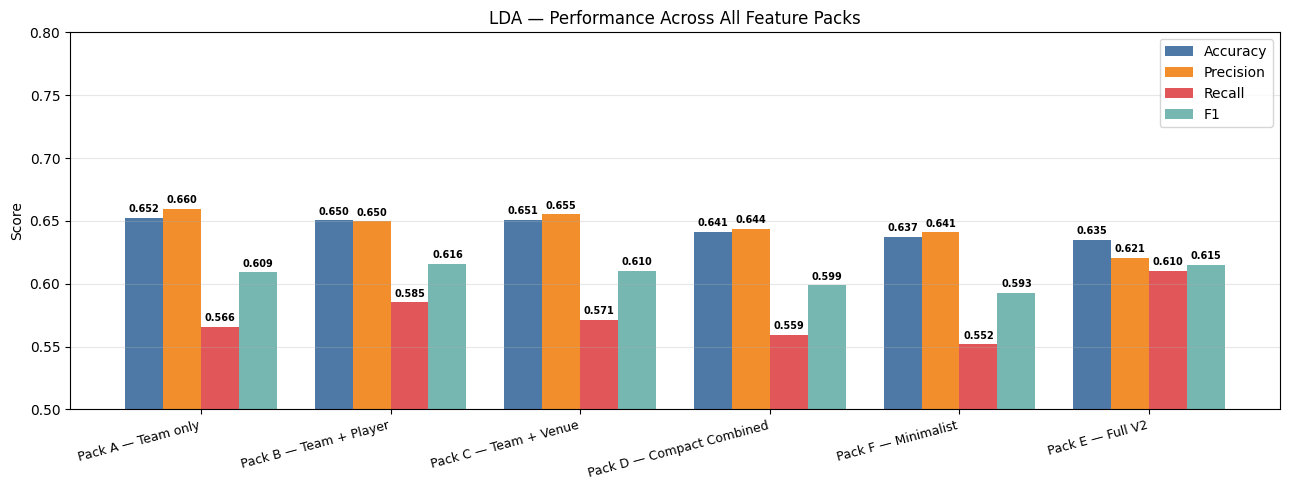

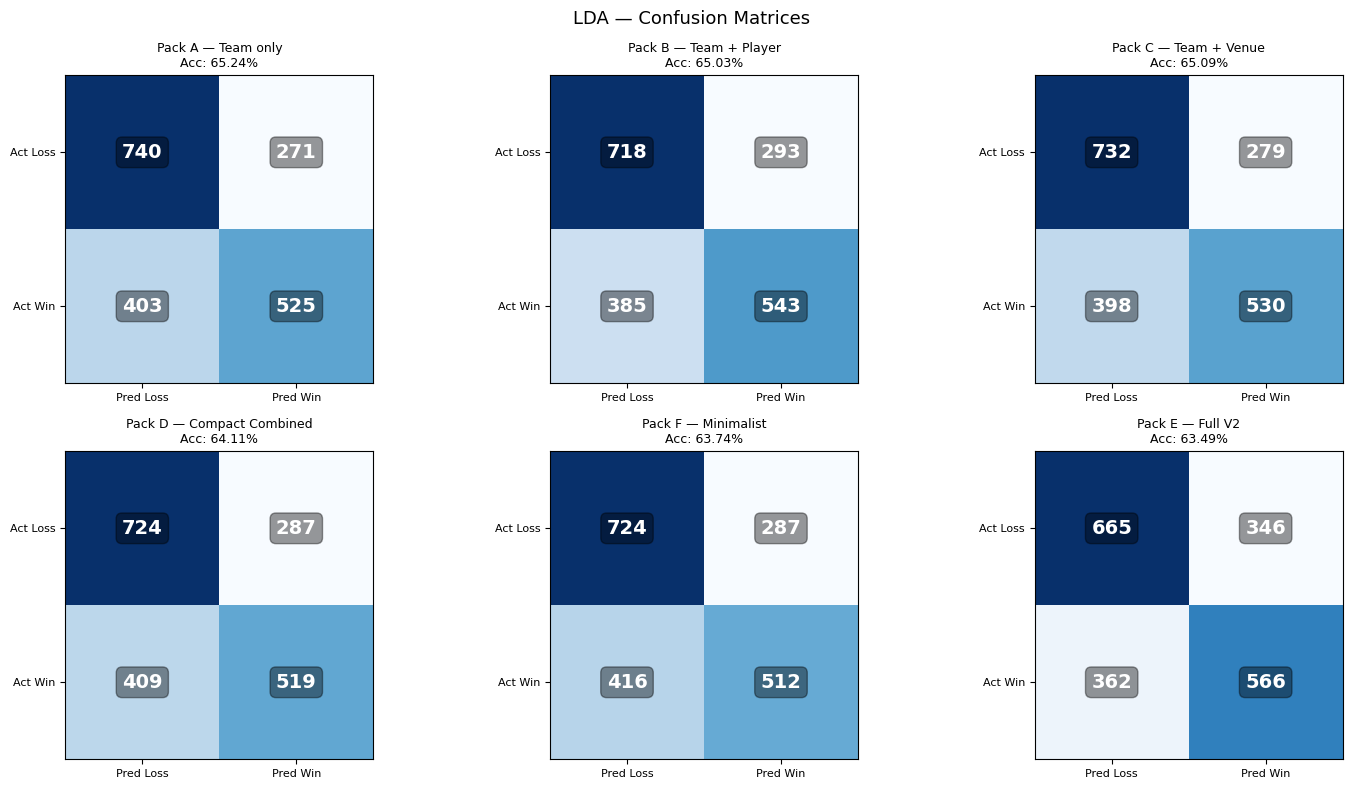

In [9]:
plot_pack_results(lda_results, 'LDA')
plot_confusion_matrices(lda_results, 'LDA')

---
## Section 3 — Support Vector Machine Linear


In [32]:
print('Training Linear SVM on all packs...')
svm_linear_results = {}

for pack_name, feature_cols in PACKS.items():
    print(f'  Training on {pack_name} ({len(feature_cols)} features)...')
    X_train, X_test, y_train, y_test = time_based_split(df, feature_cols)
    model = SVMLinearModel()
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    svm_linear_results[pack_name] = get_metrics(y_test, preds)
    print(f'  {pack_name}: Accuracy = {svm_linear_results[pack_name]["accuracy"]:.4f}')

print('\nDone.')

Training Linear SVM on all packs...
  Training on Pack A — Team only (15 features)...
[SVM Linear] Training done.
  Pack A — Team only: Accuracy = 0.6514
  Training on Pack B — Team + Player (39 features)...
[SVM Linear] Training done.
  Pack B — Team + Player: Accuracy = 0.6431
  Training on Pack C — Team + Venue (31 features)...
[SVM Linear] Training done.
  Pack C — Team + Venue: Accuracy = 0.6447
  Training on Pack D — Compact Combined (28 features)...
[SVM Linear] Training done.
  Pack D — Compact Combined: Accuracy = 0.6318
  Training on Pack F — Minimalist (15 features)...
[SVM Linear] Training done.
  Pack F — Minimalist: Accuracy = 0.6431
  Training on Pack E — Full V2 (265 features)...
[SVM Linear] Training done.
  Pack E — Full V2: Accuracy = 0.6307

Done.


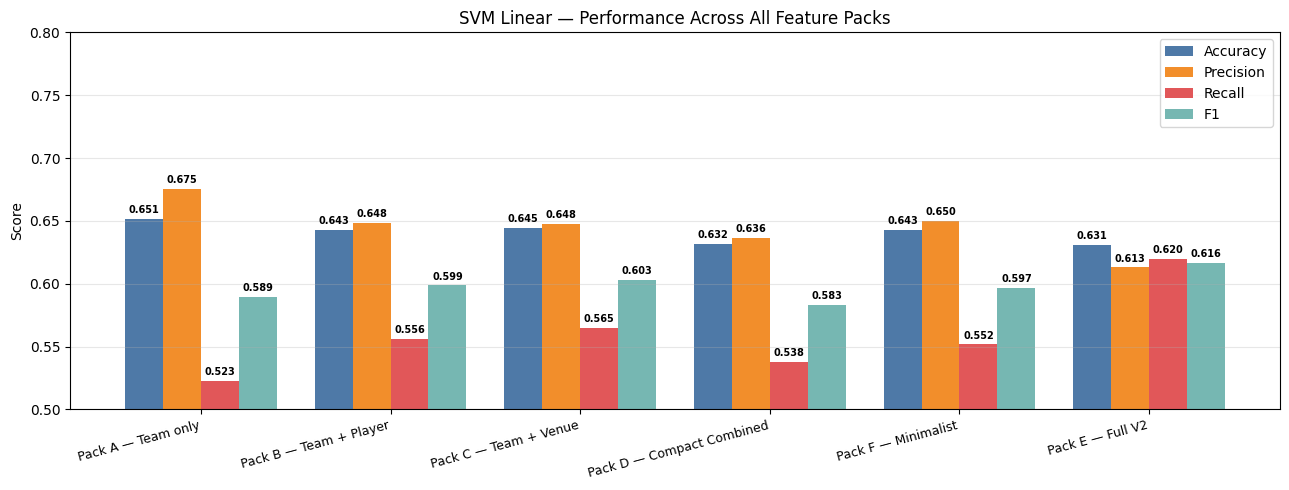

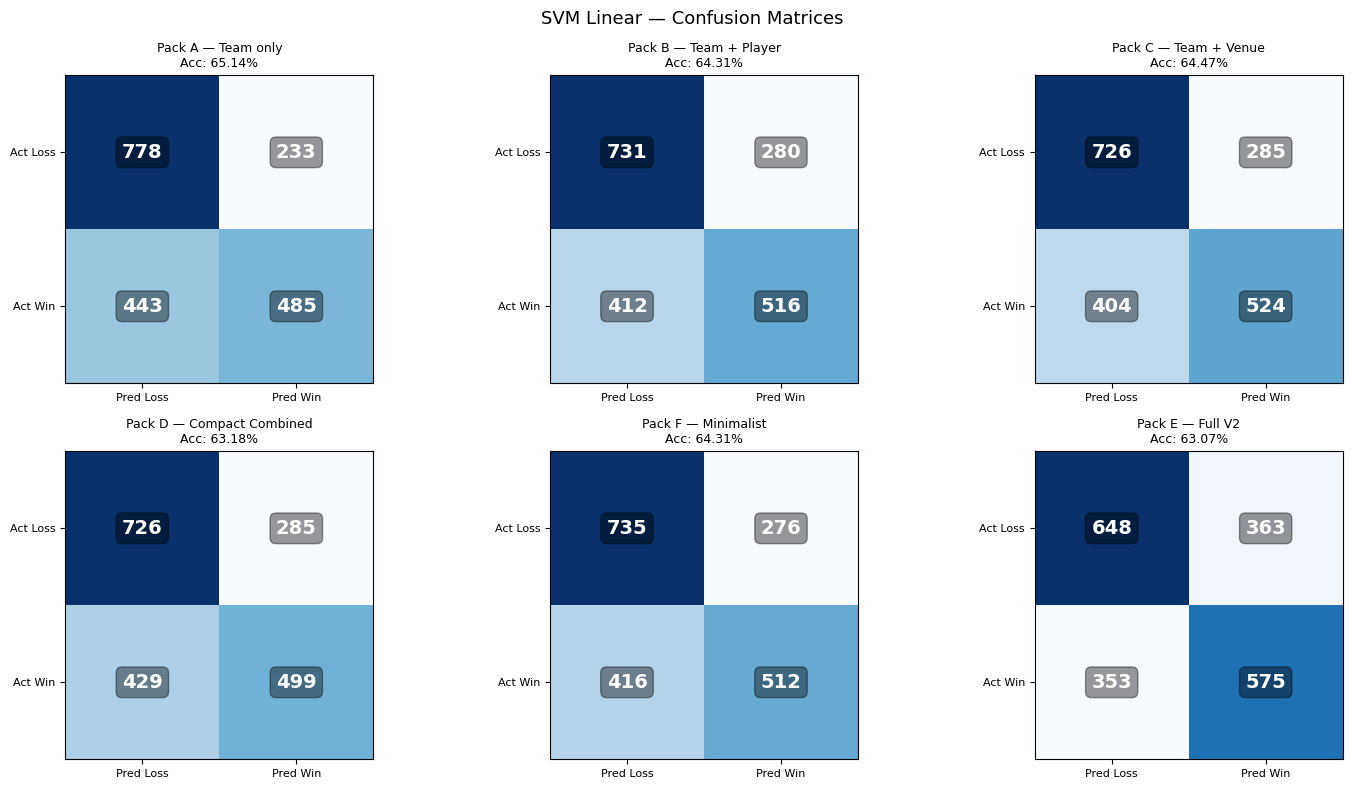

In [33]:
plot_pack_results(svm_linear_results, 'SVM Linear')
plot_confusion_matrices(svm_linear_results, 'SVM Linear')

---
## Section 4 — Final Comparison: LogReg vs LDA vs SVM Linear

In [34]:
rows = []
for pack_name in PACKS.keys():
    rows.append({
        'Pack':       pack_name,
        'LogReg':     f"{logreg_results[pack_name]['accuracy']:.4f}",
        'LDA':        f"{lda_results[pack_name]['accuracy']:.4f}",
        'SVM Linear': f"{svm_linear_results[pack_name]['accuracy']:.4f}",
    })

comparison_df = pd.DataFrame(rows).set_index('Pack')
print('=== Final Accuracy Comparison — LogReg vs LDA vs SVM Linear ===')
display(comparison_df)

=== Final Accuracy Comparison — LogReg vs LDA vs SVM Linear ===


,LogReg,LDA,SVM Linear
Pack,,,
Pack A — Team only,0.6534,0.6524,0.6514
Pack B — Team + Player,0.6447,0.6503,0.6431
Pack C — Team + Venue,0.6380,0.6509,0.6447
Pack D — Compact Combined,0.6421,0.6411,0.6318
Pack F — Minimalist,0.6369,0.6374,0.6431
Pack E — Full V2,0.6354,0.6349,0.6307


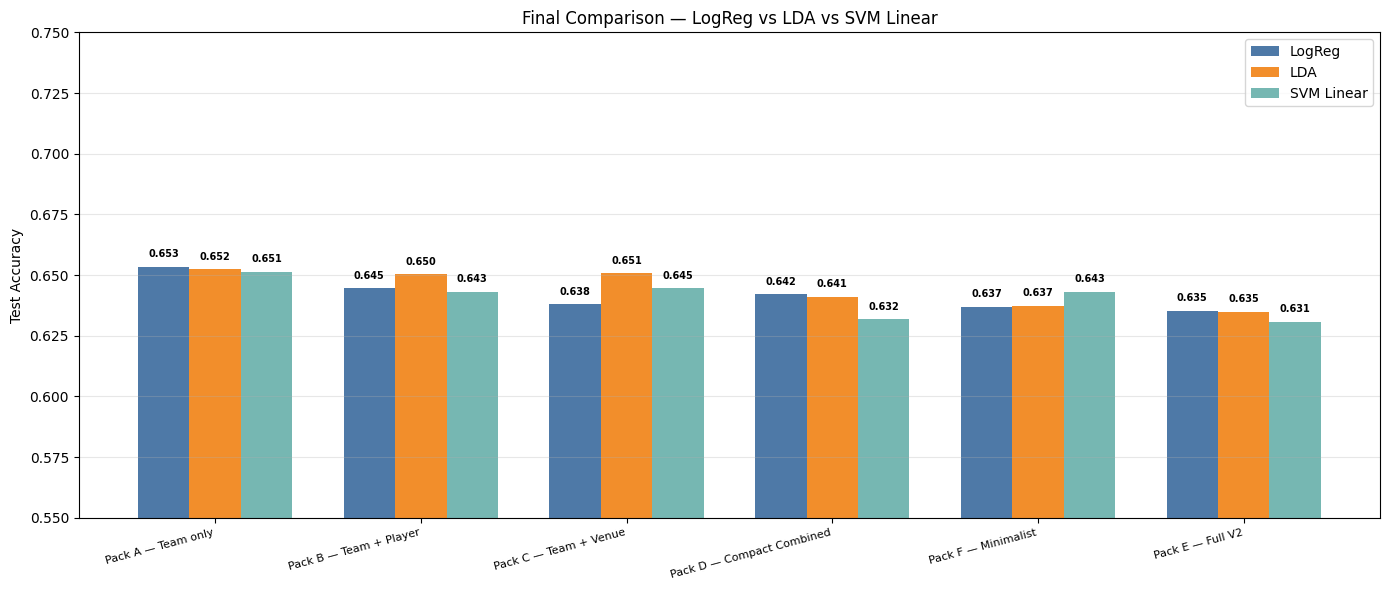

In [35]:
pack_names  = list(PACKS.keys())
model_names = ['LogReg', 'LDA', 'SVM Linear']
colors      = ['#4e79a7', '#f28e2b', '#76b7b2']
all_results = [logreg_results, lda_results, svm_linear_results]

x     = np.arange(len(pack_names))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))

for i, (model_name, color, results) in enumerate(zip(model_names, colors, all_results)):
    accuracies = [results[p]['accuracy'] for p in pack_names]
    bars = ax.bar(x + i*width, accuracies, width, label=model_name, color=color)
    for bar, acc in zip(bars, accuracies):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.003,
                f'{acc:.3f}',
                ha='center', va='bottom', fontsize=7, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels(pack_names, fontsize=8, rotation=15, ha='right')
ax.set_ylim(0.55, 0.75)
ax.set_ylabel('Test Accuracy')
ax.set_title('Final Comparison — LogReg vs LDA vs SVM Linear')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
## Section 3 — Section 5 — Support Vector Machine Non-Linear (RBF)

In [10]:
print('Training SVM on all packs...')
svm_results = {}

for pack_name, feature_cols in PACKS.items():
    print(f'  Training on {pack_name} ({len(feature_cols)} features)...')
    X_train, X_test, y_train, y_test = time_based_split(df, feature_cols)
    model = SVMModel()
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    svm_results[pack_name] = get_metrics(y_test, preds)
    print(f'  {pack_name}: Accuracy = {svm_results[pack_name]["accuracy"]:.4f}')

print('\nDone.')

Training SVM on all packs...
  Training on Pack A — Team only (15 features)...
[SVM] Training done.
  Pack A — Team only: Accuracy = 0.6447
  Training on Pack B — Team + Player (39 features)...
[SVM] Training done.
  Pack B — Team + Player: Accuracy = 0.6354
  Training on Pack C — Team + Venue (31 features)...
[SVM] Training done.
  Pack C — Team + Venue: Accuracy = 0.6509
  Training on Pack D — Compact Combined (28 features)...
[SVM] Training done.
  Pack D — Compact Combined: Accuracy = 0.6380
  Training on Pack F — Minimalist (15 features)...
[SVM] Training done.
  Pack F — Minimalist: Accuracy = 0.6271
  Training on Pack E — Full V2 (265 features)...
[SVM] Training done.
  Pack E — Full V2: Accuracy = 0.6338

Done.


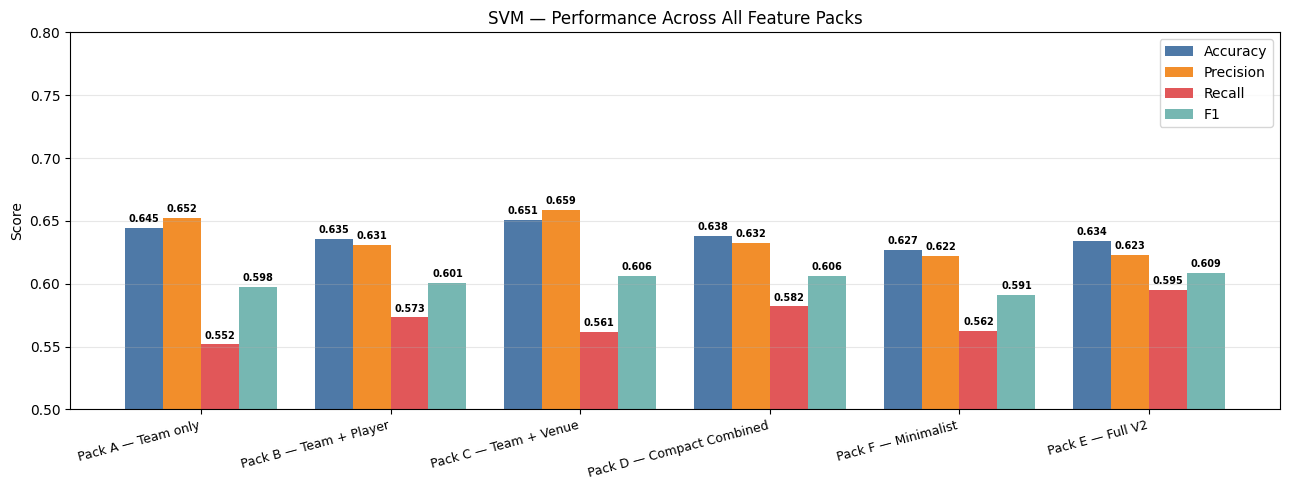

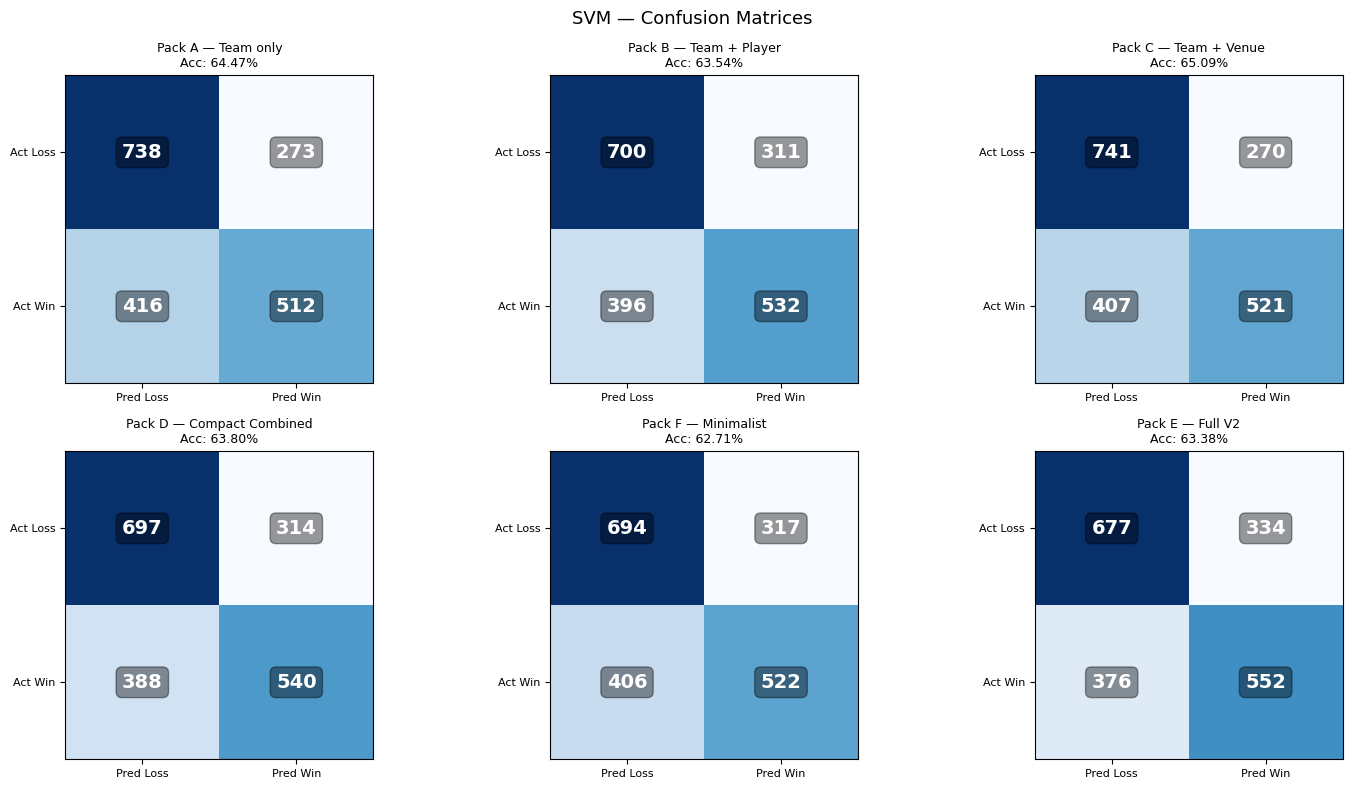

In [11]:
plot_pack_results(svm_results, 'SVM')
plot_confusion_matrices(svm_results, 'SVM')

---
## Section 6 — Feature Selection by Model Weights
### Train on all 265 features → select top 50 and top 25 by each model's weights → retrain and compare

In [37]:
from models.svm_linear import SVMLinearModel

print('Training all 3 models on 265 features...')

PACK_E = [c for c in df.columns if c not in EXCLUDE_COLS]
X_train, X_test, y_train, y_test = time_based_split(df, PACK_E)

# Train
logreg_w = LogisticRegressionModel()
logreg_w.fit(X_train, y_train)

lda_w = LDAModel()
lda_w.fit(X_train, y_train)

print('[Linear SVM] This will take several minutes...')
svm_lin_w = SVMLinearModel()
svm_lin_w.fit(X_train, y_train)

# Results on 265 features
print('\n--- Results on 265 features ---')
r265 = {
    'LogReg': get_metrics(y_test, logreg_w.predict(X_test)),
    'LDA':    get_metrics(y_test, lda_w.predict(X_test)),
    'SVM Linear': get_metrics(y_test, svm_lin_w.predict(X_test)),
}
for name, r in r265.items():
    print(f'  {name}: Accuracy = {r["accuracy"]:.4f}')

# Get weights
logreg_weights = pd.DataFrame({
    'Feature':     PACK_E,
    'Coefficient': logreg_w.model.coef_[0],
    'Abs':         abs(logreg_w.model.coef_[0])
}).sort_values('Abs', ascending=False).reset_index(drop=True)

lda_weights = pd.DataFrame({
    'Feature':     PACK_E,
    'Coefficient': lda_w.model.coef_[0],
    'Abs':         abs(lda_w.model.coef_[0])
}).sort_values('Abs', ascending=False).reset_index(drop=True)

svm_weights = pd.DataFrame({
    'Feature':     PACK_E,
    'Coefficient': svm_lin_w.model.coef_[0],
    'Abs':         abs(svm_lin_w.model.coef_[0])
}).sort_values('Abs', ascending=False).reset_index(drop=True)

print('\nWeights extracted from all 3 models.')

Training all 3 models on 265 features...
[LogReg] Training done.
[LDA] Training done.
[Linear SVM] This will take several minutes...
[SVM Linear] Training done.

--- Results on 265 features ---
  LogReg: Accuracy = 0.6354
  LDA: Accuracy = 0.6349
  SVM Linear: Accuracy = 0.6307

Weights extracted from all 3 models.


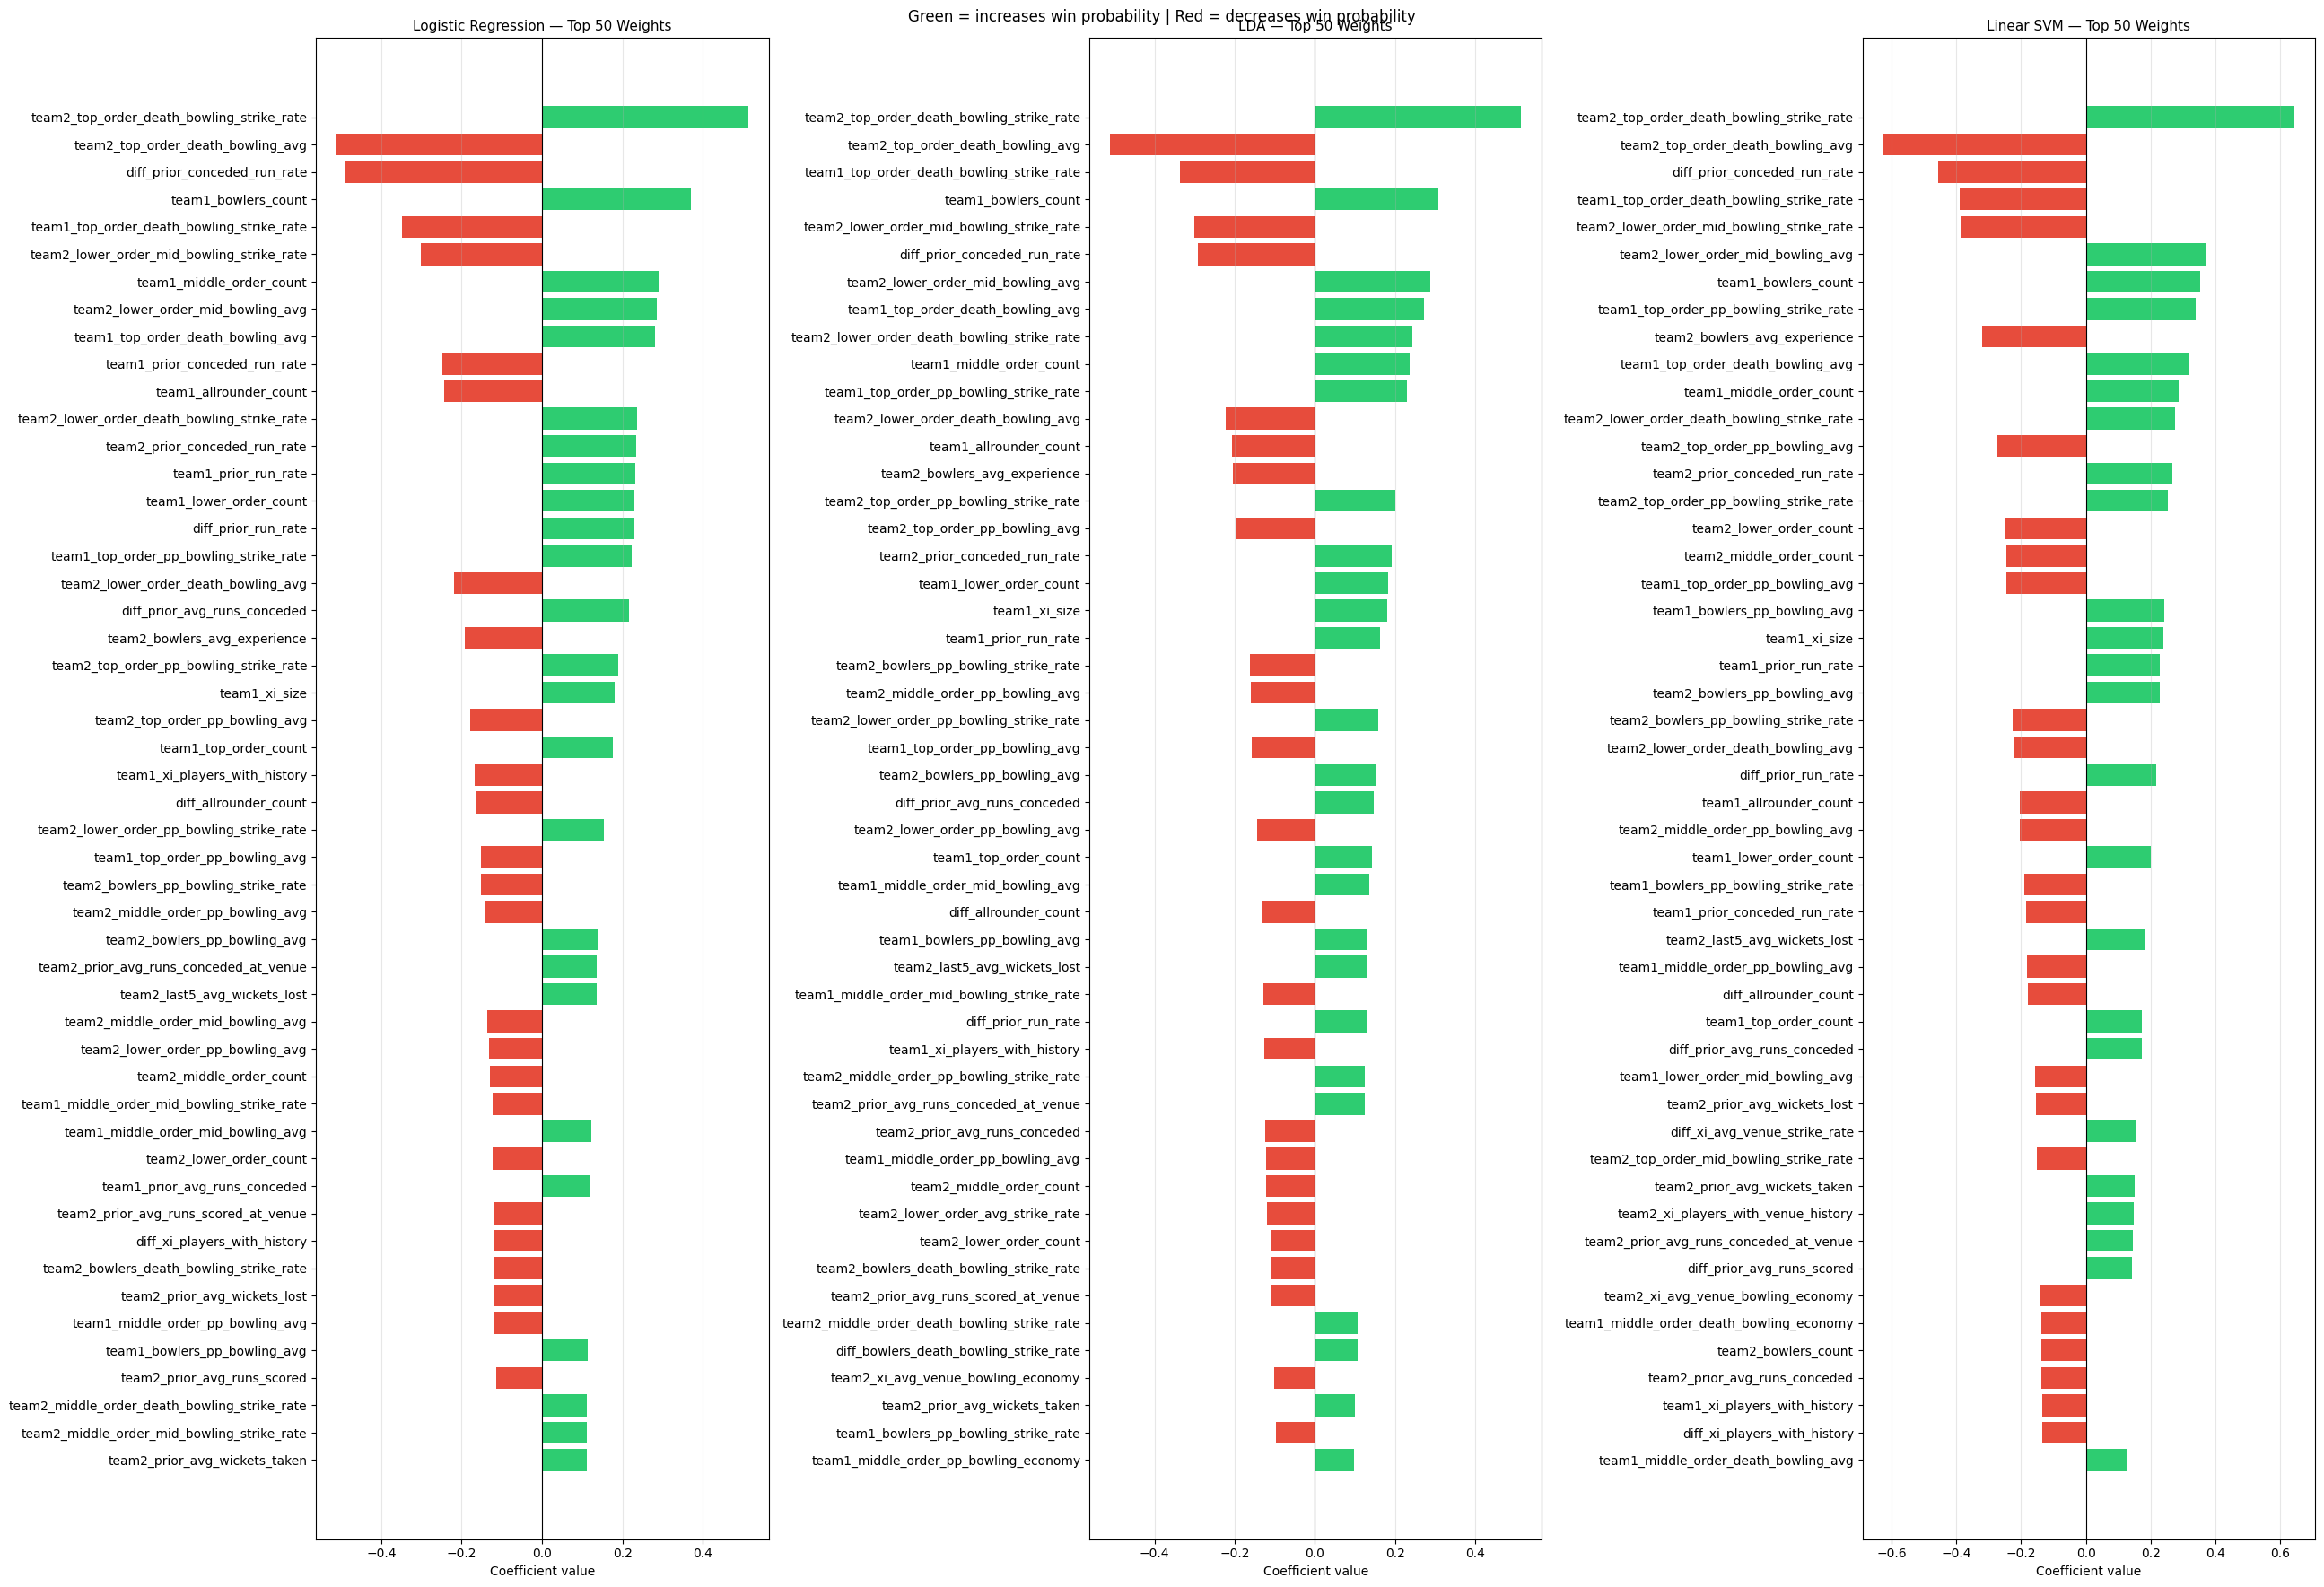

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(26, 18))

for ax, weights_df, title in zip(
    axes,
    [logreg_weights, lda_weights, svm_weights],
    ['Logistic Regression', 'LDA', 'Linear SVM'],
):
    top50 = weights_df.head(50)
    colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in top50['Coefficient'][::-1]]
    ax.barh(top50['Feature'][::-1], top50['Coefficient'][::-1], color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'{title} — Top 50 Weights', fontsize=11)
    ax.set_xlabel('Coefficient value')
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Green = increases win probability | Red = decreases win probability', fontsize=12)
plt.tight_layout()
plt.show()

In [39]:
print('===== Retraining on Top 50 Features =====')

top50_logreg = logreg_weights['Feature'].head(50).tolist()
top50_lda    = lda_weights['Feature'].head(50).tolist()
top50_svm    = svm_weights['Feature'].head(50).tolist()

r50 = {}

for selection_name, feature_cols in [
    ('Top 50 — LogReg selected',     top50_logreg),
    ('Top 50 — LDA selected',        top50_lda),
    ('Top 50 — SVM Linear selected', top50_svm),
]:
    print(f'\n--- {selection_name} ---')
    X_train_s, X_test_s, y_train_s, y_test_s = time_based_split(df, feature_cols)

    m_logreg = LogisticRegressionModel()
    m_logreg.fit(X_train_s, y_train_s)

    m_lda = LDAModel()
    m_lda.fit(X_train_s, y_train_s)

    m_svm_lin = SVMLinearModel()
    m_svm_lin.fit(X_train_s, y_train_s)

    r50[selection_name] = {
        'LogReg':       get_metrics(y_test_s, m_logreg.predict(X_test_s)),
        'LDA':          get_metrics(y_test_s, m_lda.predict(X_test_s)),
        'SVM Linear':   get_metrics(y_test_s, m_svm_lin.predict(X_test_s)),
    }

    for model_name, r in r50[selection_name].items():
        print(f'  {model_name}: Accuracy = {r["accuracy"]:.4f}')

print('\nDone.')

===== Retraining on Top 50 Features =====

--- Top 50 — LogReg selected ---
[LogReg] Training done.
[LDA] Training done.
[SVM Linear] Training done.
  LogReg: Accuracy = 0.6276
  LDA: Accuracy = 0.6261
  SVM Linear: Accuracy = 0.6173

--- Top 50 — LDA selected ---
[LogReg] Training done.
[LDA] Training done.
[SVM Linear] Training done.
  LogReg: Accuracy = 0.6158
  LDA: Accuracy = 0.6158
  SVM Linear: Accuracy = 0.6173

--- Top 50 — SVM Linear selected ---
[LogReg] Training done.
[LDA] Training done.
[SVM Linear] Training done.
  LogReg: Accuracy = 0.6235
  LDA: Accuracy = 0.6158
  SVM Linear: Accuracy = 0.6163

Done.


In [40]:
print('===== Retraining on Top 25 Features =====')

top25_logreg = logreg_weights['Feature'].head(25).tolist()
top25_lda    = lda_weights['Feature'].head(25).tolist()
top25_svm    = svm_weights['Feature'].head(25).tolist()

r25 = {}

for selection_name, feature_cols in [
    ('Top 25 — LogReg selected',     top25_logreg),
    ('Top 25 — LDA selected',        top25_lda),
    ('Top 25 — SVM Linear selected', top25_svm),
]:
    print(f'\n--- {selection_name} ---')
    X_train_s, X_test_s, y_train_s, y_test_s = time_based_split(df, feature_cols)

    m_logreg = LogisticRegressionModel()
    m_logreg.fit(X_train_s, y_train_s)

    m_lda = LDAModel()
    m_lda.fit(X_train_s, y_train_s)

    m_svm_lin = SVMLinearModel()
    m_svm_lin.fit(X_train_s, y_train_s)

    r25[selection_name] = {
        'LogReg':       get_metrics(y_test_s, m_logreg.predict(X_test_s)),
        'LDA':          get_metrics(y_test_s, m_lda.predict(X_test_s)),
        'SVM Linear':   get_metrics(y_test_s, m_svm_lin.predict(X_test_s)),
    }

    for model_name, r in r25[selection_name].items():
        print(f'  {model_name}: Accuracy = {r["accuracy"]:.4f}')

print('\nDone.')

===== Retraining on Top 25 Features =====

--- Top 25 — LogReg selected ---
[LogReg] Training done.
[LDA] Training done.
[SVM Linear] Training done.
  LogReg: Accuracy = 0.6215
  LDA: Accuracy = 0.6153
  SVM Linear: Accuracy = 0.6220

--- Top 25 — LDA selected ---
[LogReg] Training done.
[LDA] Training done.
[SVM Linear] Training done.
  LogReg: Accuracy = 0.5817
  LDA: Accuracy = 0.5848
  SVM Linear: Accuracy = 0.5895

--- Top 25 — SVM Linear selected ---
[LogReg] Training done.
[LDA] Training done.
[SVM Linear] Training done.
  LogReg: Accuracy = 0.6147
  LDA: Accuracy = 0.6209
  SVM Linear: Accuracy = 0.6158

Done.


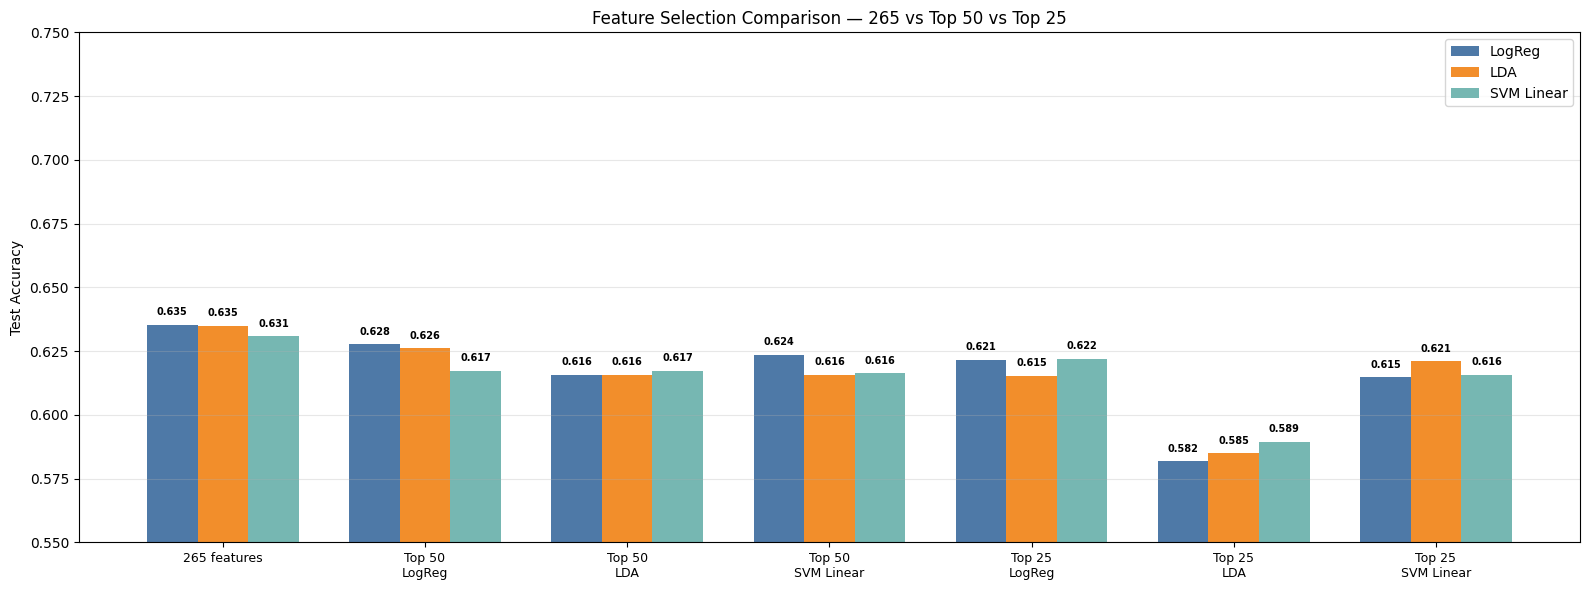

In [41]:
fig, ax = plt.subplots(figsize=(16, 6))

experiment_names = [
    '265 features',
    'Top 50\nLogReg',
    'Top 50\nLDA',
    'Top 50\nSVM Linear',
    'Top 25\nLogReg',
    'Top 25\nLDA',
    'Top 25\nSVM Linear',
]

model_names = ['LogReg', 'LDA', 'SVM Linear']
colors      = ['#4e79a7', '#f28e2b', '#76b7b2']

x     = np.arange(len(experiment_names))
width = 0.25

for i, (model_name, color) in enumerate(zip(model_names, colors)):
    accuracies = [
        r265[model_name]['accuracy'],
        r50['Top 50 — LogReg selected'][model_name]['accuracy'],
        r50['Top 50 — LDA selected'][model_name]['accuracy'],
        r50['Top 50 — SVM Linear selected'][model_name]['accuracy'],
        r25['Top 25 — LogReg selected'][model_name]['accuracy'],
        r25['Top 25 — LDA selected'][model_name]['accuracy'],
        r25['Top 25 — SVM Linear selected'][model_name]['accuracy'],
    ]

    bars = ax.bar(x + i*width, accuracies, width, label=model_name, color=color)
    for bar, acc in zip(bars, accuracies):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.003,
                f'{acc:.3f}',
                ha='center', va='bottom', fontsize=7, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels(experiment_names, fontsize=9)
ax.set_ylim(0.55, 0.75)
ax.set_ylabel('Test Accuracy')
ax.set_title('Feature Selection Comparison — 265 vs Top 50 vs Top 25')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()